
ACTIVITY 3 :VISUALIZATION REDESING

Cesar Antonio Pinto May 12/01/2026




set up libraries

## PART 1: WORKSHOP CODE (REFERENCE ONLY)
DO NOT MODIFY THIS SECTION - FOR REFERENCE ONLY

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Data Loading & Exploration
[Code cell - from workshop]

In [ ]:
df=pd.read_csv('/content/act3.csv')
print(df.head)
print("="*50)
df.info()

<bound method NDFrame.head of              date region    product  sales  profit  quantity
0      2001-01-01   West  Product A  206.0   216.0        24
1      2001-01-01  north  Product A  752.0   197.0        22
2      2001-01-01   East  Product D  836.0   281.0        37
3      2001-01-02  north  Product B  406.0   235.0        47
4      2001-01-02  north  Product B  959.0    28.0        44
...           ...    ...        ...    ...     ...       ...
20015  2021-10-03  north  Product A    NaN   -25.0        33
20016  2005-05-12  NORTH  Product A  315.0   178.0        33
20017  2013-08-13  North  Product D  318.0   135.0        14
20018  2012-03-30  north  Product B  831.0   250.0        22
20019  2010-07-07   West  Product B  701.0   234.0         5

[20020 rows x 6 columns]>
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20020 entries, 0 to 20019
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      20020 non-

In [ ]:
df.describe()
#-sales we cannot have negative sales
# profits we can have negative
#data concistency , hig std means outliers


,sales,profit,quantity
count,18230.000000,19019.000000,20020.000000
mean,1750.814098,124.772228,25.131968
std,22192.205694,100.953809,14.059338
min,-324389.000000,-50.000000,1.000000
25%,320.000000,37.000000,13.000000
50%,547.500000,125.000000,25.000000
75%,775.000000,212.000000,37.000000
max,495070.000000,299.000000,49.000000


In [ ]:
print(df.dtypes)

date         object
region       object
product      object
sales       float64
profit      float64
quantity      int64
dtype: object


### Data Debugging
[Code cell - from workshop]


In [ ]:
print("=" * 50)
print("MISSING VALUES")
print("=" * 50)
print("\nCount of missing values per column:")
print(df.isnull().sum())
print("\nPercentage of missing values per column:")
print((df.isnull().sum() / len(df) * 100).round(2))

MISSING VALUES

Count of missing values per column:
date           0
region         0
product        0
sales       1790
profit      1001
quantity       0
dtype: int64

Percentage of missing values per column:
date        0.00
region      0.00
product     0.00
sales       8.94
profit      5.00
quantity    0.00
dtype: float64


In [ ]:
# PROBLEM 2: Check for duplicate rows
print("=" * 50)
print("DUPLICATE ROWS")
print("=" * 50)
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")
# Show the duplicate rows
if df.duplicated().sum() > 0:
  print("\nDuplicate rows:")
  duplicates = df[df.duplicated(keep=False)].sort_values(by=list(df.columns))
  print(duplicates)
  #regions names dont have an standart name we should clean
  #date are not date-type


DUPLICATE ROWS

Number of duplicate rows: 20

Duplicate rows:
             date region    product  sales  profit  quantity
1412   2002-10-07  NORTH  Product A  583.0    67.0        40
20012  2002-10-07  NORTH  Product A  583.0    67.0        40
1628   2003-01-14  north  Product C    NaN   144.0         9
20009  2003-01-14  north  Product C    NaN   144.0         9
2182   2003-09-24  north  Product B  514.0   256.0        24
20007  2003-09-24  north  Product B  514.0   256.0        24
2367   2003-12-17   West  Product B    NaN    65.0        38
20001  2003-12-17   West  Product B    NaN    65.0        38
2610   2004-04-06  North  Product C  904.0   227.0        46
20013  2004-04-06  North  Product C  904.0   227.0        46
3013   2004-10-07   West  Product B  707.0   -17.0        33
20004  2004-10-07   West  Product B  707.0   -17.0        33
3489   2005-05-12  NORTH  Product A  315.0   178.0        33
20016  2005-05-12  NORTH  Product A  315.0   178.0        33
3491   2005-05-13   Eas

In [ ]:
# PROBLEM 4: Check for inconsistencies in categorical data
print("=" * 50)
print("CATEGORICAL DATA INCONSISTENCIES")
print("=" * 50)
print("\nUnique values in 'region' column:")
print(df['region'].value_counts())
print("\nNotice: 'North', 'north', 'NORTH' should be the same!")
print("\nUnique values in 'product' column:")
print(df['product'].value_counts())

CATEGORICAL DATA INCONSISTENCIES

Unique values in 'region' column:
region
north    3401
South    3388
North    3352
West     3342
NORTH    3317
East     3220
Name: count, dtype: int64

Notice: 'North', 'north', 'NORTH' should be the same!

Unique values in 'product' column:
product
Product D    5076
Product A    5062
Product C    4972
Product B    4910
Name: count, dtype: int64


In [ ]:
# This will give WRONG results:
df.groupby('region')['sales'].sum()
# Returns: north, North, NORTH as THREE separate regions!

,sales
region,
East,6054599.0
NORTH,3959206.0
North,5406961.0
South,5473491.0
West,5835321.0
north,5187763.0


#The problem with outliers is the lack of accuracy , when we use the mean
|

VISUAL INSPECTION FOR OUTLIERS


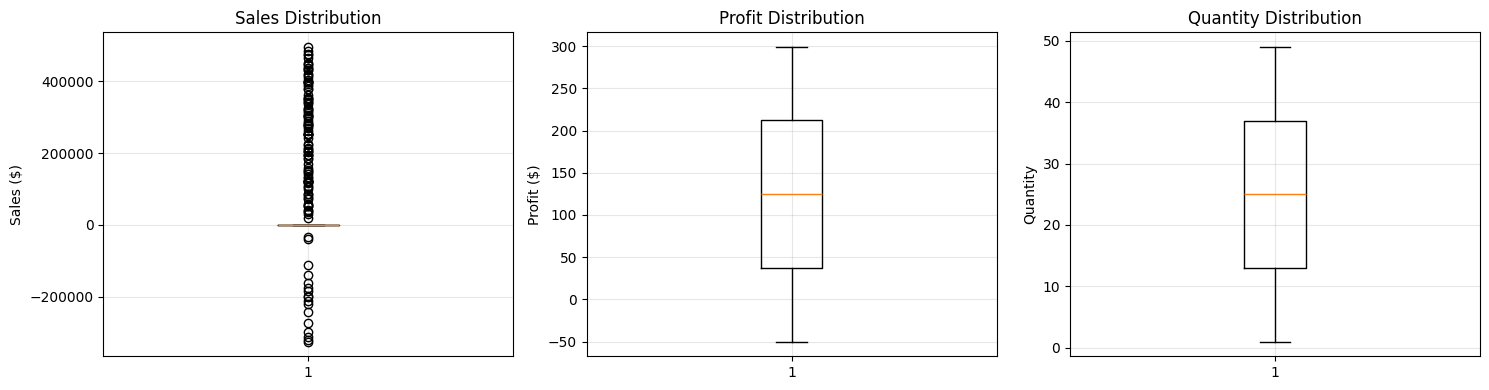

In [ ]:
# PROBLEM 5: Check for outliers using boxplot
print("=" * 50)
print("VISUAL INSPECTION FOR OUTLIERS")
print("=" * 50)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# Boxplot for sales
axes[0].boxplot(df['sales'].dropna())
axes[0].set_title('Sales Distribution')
axes[0].set_ylabel('Sales ($)')
axes[0].grid(True, alpha=0.3)
# Boxplot for profit
axes[1].boxplot(df['profit'].dropna())
axes[1].set_title('Profit Distribution')
axes[1].set_ylabel('Profit ($)')
axes[1].grid(True, alpha=0.3)
# Boxplot for quantity
axes[2].boxplot(df['quantity'].dropna())
axes[2].set_title('Quantity Distribution')
axes[2].set_ylabel('Quantity')
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# PROBLEM 6: Check for invalid/impossible values
print("=" * 50)
print("INVALID VALUES CHECK")
print("=" * 50)
# Check for negative sales (sales should never be negative!)
negative_sales = df[df['sales'] < 0]
print(f"\nRows with NEGATIVE sales (ERROR!): {len(negative_sales)}")
if len(negative_sales) > 0:
  print(negative_sales[['date', 'region', 'product', 'sales']])
# Check extreme values in sales
  extreme_sales = df[df['sales'] > 2000]
  print(f"\nRows with EXTREME sales (>$2000): {len(extreme_sales)}")
if len(extreme_sales) > 0:
  print(extreme_sales[['date', 'region', 'product', 'sales']])

INVALID VALUES CHECK

Rows with NEGATIVE sales (ERROR!): 17
             date region    product     sales
592    2001-09-28  North  Product A  -34205.0
5694   2008-02-13   East  Product D -240958.0
6647   2009-04-23   West  Product A -111248.0
7804   2010-10-04  North  Product C -324389.0
8322   2011-05-28  NORTH  Product B -137877.0
10329  2013-11-29  north  Product C -212683.0
10991  2014-09-28  South  Product C -174173.0
12209  2016-04-06  South  Product A -297982.0
12538  2016-09-03  north  Product C -220083.0
13287  2017-08-11  North  Product A -321441.0
13944  2018-06-07  NORTH  Product A -198906.0
14418  2019-01-09  South  Product A -310785.0
16073  2021-02-03  South  Product A -182524.0
18172  2023-09-19  South  Product A -199845.0
18329  2023-11-30  NORTH  Product D -272779.0
19382  2025-03-25   East  Product D -161816.0
19462  2025-04-30  north  Product B  -37957.0

Rows with EXTREME sales (>$2000): 100
             date region    product     sales
75     2001-02-04  north  P

In [ ]:
# SUMMARY: List all problems found
print("=" * 60)
print("SUMMARY OF DATA QUALITY ISSUES FOUND")
print("=" * 60)
print("\n1. Missing Values:")
print(f"- Sales: {df['sales'].isnull().sum()} missing "
f"({(df['sales'].isnull().sum()/len(df)*100):.1f}%)")
print(f"- Profit: {df['profit'].isnull().sum()} missing "
f"({(df['profit'].isnull().sum()/len(df)*100):.1f}%)")
print("\n2. Duplicate Rows:")
print(f"- {df.duplicated().sum()} duplicate rows found")
print("\n3. Data Type Issues:")
print(f"- 'date' column is stored as string, should be datetime")
print("\n4. Inconsistencies:")
print(f"- 'region' has inconsistent capitalization: {df['region'].unique()}")
print("\n5. Invalid Values:")
print(f"- {len(df[df['sales'] < 0])} rows with negative sales (impossible!)")
print("\n6. Outliers:")
print(f"- {len(df[df['sales'] > 2000])} rows with extreme sales values")
print("\n" + "=" * 60)

SUMMARY OF DATA QUALITY ISSUES FOUND

1. Missing Values:
- Sales: 1790 missing (8.9%)
- Profit: 1001 missing (5.0%)

2. Duplicate Rows:
- 20 duplicate rows found

3. Data Type Issues:
- 'date' column is stored as string, should be datetime

4. Inconsistencies:
- 'region' has inconsistent capitalization: ['West' 'north' 'East' 'South' 'NORTH' 'North']

5. Invalid Values:
- 17 rows with negative sales (impossible!)

6. Outliers:
- 100 rows with extreme sales values



### Data Cleaning
[Code cell - from workshop]

• Data Cleaning: Fixing structural issues (types, duplicates, format)


• Data Cleansing: Handling quality issues (missing values, outliers, validation)

In [ ]:
# Create a copy of the original data (best practice!)
df_clean = df.copy()
print("Creating a clean copy of the data...")
print(f"Original dataset: {len(df)} rows")

Creating a clean copy of the data...
Original dataset: 20020 rows


In [ ]:
# STEP 1: Remove duplicate rows
print("=" * 50)
print("STEP 1: REMOVING DUPLICATES")
print("=" * 50)
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)
print(f"Rows before: {before}")
print(f"Rows after: {after}")
print(f"Duplicates removed: {before - after}")

STEP 1: REMOVING DUPLICATES
Rows before: 20020
Rows after: 20000
Duplicates removed: 20


In [ ]:
# STEP 2: Fix data types - Convert date to datetime
print("=" * 50)
print("STEP 2: FIXING DATA TYPES")
print("=" * 50)
print("Before conversion:")
print(f" date column type: {df_clean['date'].dtype}")
df_clean['date'] = pd.to_datetime(df_clean['date'])
print("\nAfter conversion:")
print(f" date column type: {df_clean['date'].dtype}")
print(" Date column is now datetime!")

STEP 2: FIXING DATA TYPES
Before conversion:
 date column type: object

After conversion:
 date column type: datetime64[ns]
 Date column is now datetime!


df_clean['region'] = df_clean['region'].str.title()
this line of code help us with the data standarizaton
by using methods

In [ ]:
# STEP 3: Standardize categorical data (fix capitalization)
print("=" * 50)
print("STEP 3: STANDARDIZING CATEGORICAL DATA")
print("=" * 50)
print("Before standardization:")
print(df_clean['region'].value_counts())
# Convert all regions to title case (North, South, East, West)
df_clean['region'] = df_clean['region'].str.title()
print("\nAfter standardization:")
print(df_clean['region'].value_counts())
print("Region names are now consistent!")

STEP 3: STANDARDIZING CATEGORICAL DATA
Before standardization:
region
north    3395
South    3388
North    3349
West     3339
NORTH    3313
East     3216
Name: count, dtype: int64

After standardization:
region
North    10057
South     3388
West      3339
East      3216
Name: count, dtype: int64
Region names are now consistent!


negative numbers turn in to a nan
by using a mask to agrupate, detect negative and turn into a nan

In [ ]:
# STEP 4: Handle invalid values (negative sales)
print("=" * 50)
print("STEP 4: HANDLING INVALID VALUES")
print("=" * 50)
# Find negative sales
negative_mask = df_clean['sales'] < 0
print(f"Rows with negative sales: {negative_mask.sum()}")
# Option 1: Remove rows with negative sales
# df_clean = df_clean[df_clean['sales'] >= 0]
# Option 2: Set negative sales to NaN
# (we'll handle with other missing values)
df_clean.loc[negative_mask, 'sales'] = np.nan
print(f" Negative sales converted to NaN")
print(f" Total NaN in sales now: "
f"{df_clean['sales'].isnull().sum()}")

STEP 4: HANDLING INVALID VALUES
Rows with negative sales: 17
 Negative sales converted to NaN
 Total NaN in sales now: 1802


handeling outliers
IQR method
"FIJAR EL VALOR MAXIMO DE LOS OUTLIERS "

calculate limits of Q1 and Q4

rangue Q3-Q1
LOWER Q
"FIJAR EL VALOR MINIMO DE LOS OUTLIERS"

In [ ]:
# STEP 5: Handle outliers
print("=" * 50)
print("STEP 5: HANDLING OUTLIERS")
print("=" * 50)
# Calculate outlier boundaries using IQR method
Q1 = df_clean['sales'].quantile(0.25)
Q3 = df_clean['sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"Sales IQR boundaries:")
print(f" Lower bound: ${lower_bound:.2f}")
print(f" Upper bound: ${upper_bound:.2f}")
# Identify outliers
outliers_mask = ((df_clean['sales'] < lower_bound) |
(df_clean['sales'] > upper_bound))
print(f"\nOutliers found: {outliers_mask.sum()}")
# Option 1: Remove outliers
# df_clean = df_clean[~outliers_mask]
# Option 2: Cap outliers at boundary (winsorization)
df_clean.loc[df_clean['sales'] > upper_bound,
'sales'] = upper_bound
df_clean.loc[df_clean['sales'] < lower_bound,
'sales'] = lower_bound
print(f"Outliers capped at boundaries")

STEP 5: HANDLING OUTLIERS
Sales IQR boundaries:
 Lower bound: $-360.00
 Upper bound: $1456.00

Outliers found: 100
Outliers capped at boundaries


WHEN USE A LOGARITHMIC METHOD

when ther´s a lot of biased data
and for missing values use the median avoid use the mean ćause it is modified



In [ ]:
# STEP 6: Handle missing values
print("=" * 50)
print("STEP 6: HANDLING MISSING VALUES")
print("=" * 50)
print("Missing values before treatment:")
print(df_clean.isnull().sum())
# Strategy for 'sales': Fill with median (robust to outliers)
sales_median = df_clean['sales'].median()
df_clean['sales'] = df_clean['sales'].fillna(sales_median)
print(f"\n Filled missing sales with median: "
f"${sales_median:.2f}")
# Strategy for 'profit': Fill with median
profit_median = df_clean['profit'].median()
df_clean['profit'] = df_clean['profit'].fillna(profit_median)
print(f" Filled missing profit with median: "
f"${profit_median:.2f}")
print("\nMissing values after treatment:")
print(df_clean.isnull().sum())

STEP 6: HANDLING MISSING VALUES
Missing values before treatment:
date           0
region         0
product        0
sales       1802
profit      1000
quantity       0
dtype: int64

 Filled missing sales with median: $548.00
 Filled missing profit with median: $125.00

Missing values after treatment:
date        0
region      0
product     0
sales       0
profit      0
quantity    0
dtype: int64


we resest the index after modifie the data set and remove

In [ ]:
# STEP 7: Reset index after all cleaning
df_clean = df_clean.reset_index(drop=True)
print("\n Index reset")
print("=" * 60)
print("CLEANING COMPLETE - FINAL VALIDATION")
print("=" * 60)
print(f"\n1. Total rows: {len(df_clean)}")
print(f"2. Missing values: {df_clean.isnull().sum().sum()}")
print(f"3. Duplicates: {df_clean.duplicated().sum()}")
print(f"4. Negative sales: {(df_clean['sales'] < 0).sum()}")
print(f"5. Data types correct: "
f"{df_clean['date'].dtype == 'datetime64[ns]'}")
print(f"6. Regions standardized: "
f"{len(df_clean['region'].unique())} unique values")
print("\n" + "=" * 60)
print(" DATA IS NOW CLEAN AND READY FOR VISUALIZATION!")
print("=" * 60)


 Index reset
CLEANING COMPLETE - FINAL VALIDATION

1. Total rows: 20000
2. Missing values: 0
3. Duplicates: 0
4. Negative sales: 0
5. Data types correct: True
6. Regions standardized: 4 unique values

 DATA IS NOW CLEAN AND READY FOR VISUALIZATION!


### Workshop Visualization 1: Sales by Region
[Code cell - from workshop]


In [ ]:
# Now that our data is clean, let's create meaningful visualizations!
print("=" * 60)
print("CREATING VISUALIZATIONS WITH CLEAN DATA")
print("=" * 60)

CREATING VISUALIZATIONS WITH CLEAN DATA



1. Sales by Region
----------------------------------------


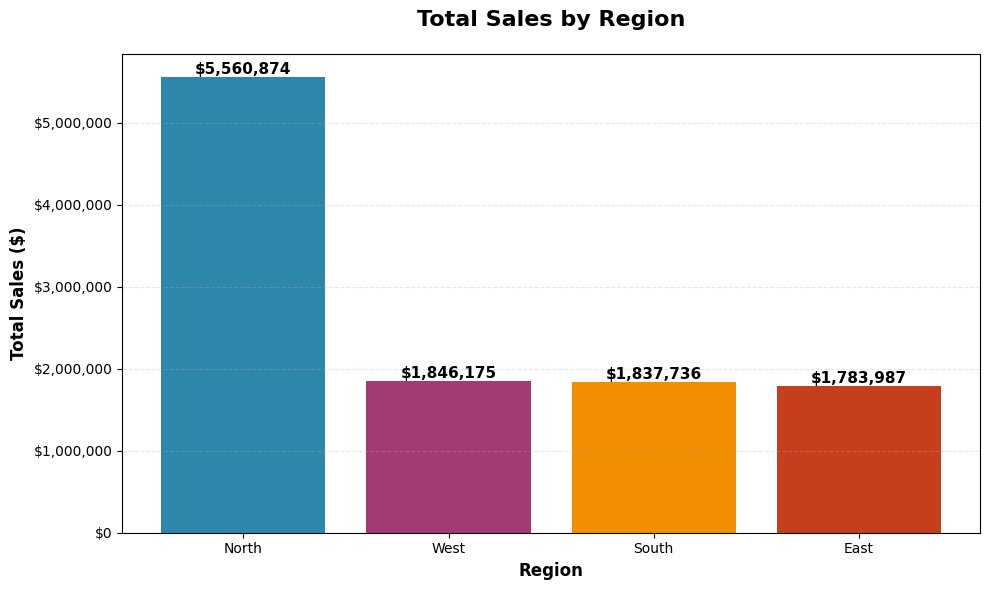

 Best performing region: North with $5,560,874.00


In [ ]:
# VISUALIZATION 1: Sales by Region (Bar Chart)
print("\n1. Sales by Region")
print("-" * 40)
# Aggregate data we grouped by regions and sales from df clean
sales_by_region = (df_clean.groupby('region')['sales']
                  .sum()
                  .sort_values(ascending=False))

# Create bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(sales_by_region.index,sales_by_region.values,color=['#2E86AB', '#A23B72','#F18F01', '#C73E1D'])


for bar in bars:
  height = bar.get_height()
  plt.text(bar.get_x() + bar.get_width()/2., height,f'${height:,.0f}',ha='center', va='bottom',fontsize=11, fontweight='bold')

plt.title('Total Sales by Region',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Region', fontsize=12, fontweight='bold')
plt.ylabel('Total Sales ($)', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')

ax = plt.gca()
ax.yaxis.set_major_formatter(
plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

print(f" Best performing region: {sales_by_region.index[0]} "
f"with ${sales_by_region.values[0]:,.2f}")


### Workshop Visualization 2: Sales Trend Over Time
[Code cell - from workshop]

cambiar a trimestre


2. Sales Trend Over Time
----------------------------------------


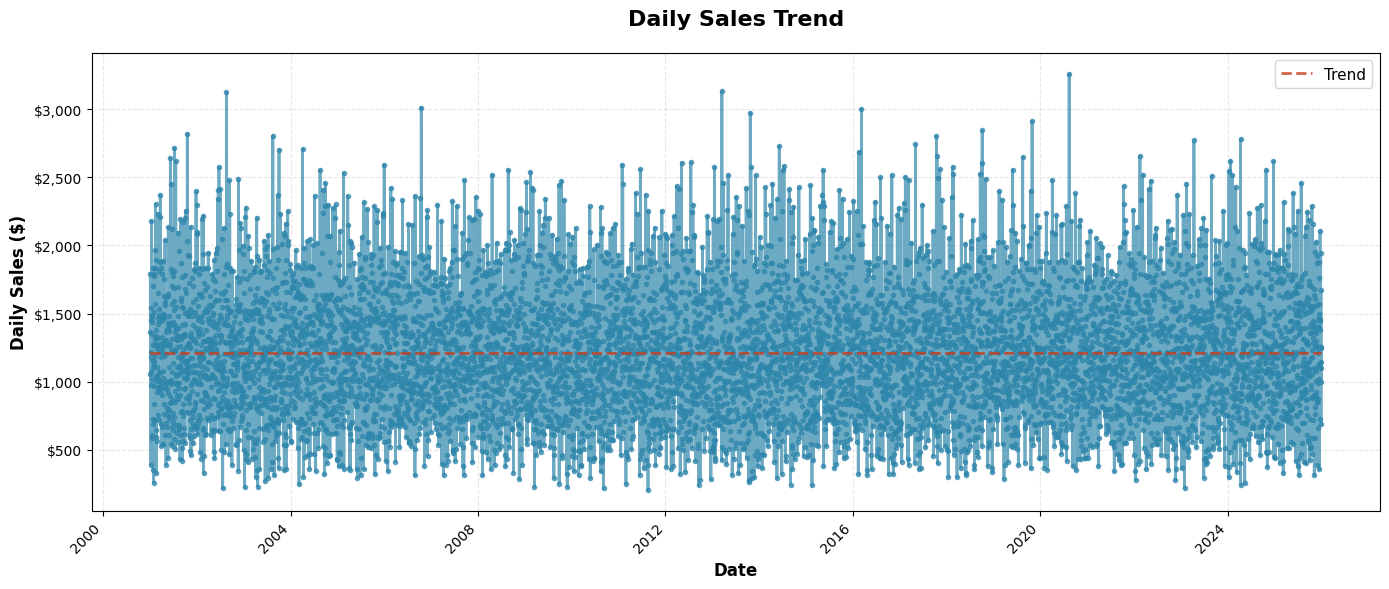

 Average daily sales: $1,207.71
 Trend: Increasing


In [ ]:
# VISUALIZATION 2: Sales Trend Over Time (Line Chart)
print("\n2. Sales Trend Over Time")
print("-" * 40)

# Aggregate data by date
sales_by_date = (df_clean.groupby('date')['sales']
                .sum()
                .reset_index())

#Create line chart
plt.figure(figsize=(14, 6))
plt.plot(sales_by_date['date'], sales_by_date['sales'],
        linewidth=2, color='#2E86AB',
        marker='o', markersize=3, alpha=0.7)

z = np.polyfit(range(len(sales_by_date)),
              sales_by_date['sales'], 1)

p = np.poly1d(z)
plt.plot(sales_by_date['date'],
        p(range(len(sales_by_date))),
        "--", color='#C73E1D',
        linewidth=2, alpha=0.8, label='Trend')



# Formatting
plt.title('Daily Sales Trend',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Daily Sales ($)', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=11)
# Format y-axis
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(f" Average daily sales: "f"${sales_by_date['sales'].mean():,.2f}")
print(f" Trend: {'Increasing' if z[0] > 0 else 'Decreasing'}")

### Workshop Visualization 3: Sales by Product
[Code cell - from workshop]

adjust scale



3. Sales Distribution by Product
----------------------------------------


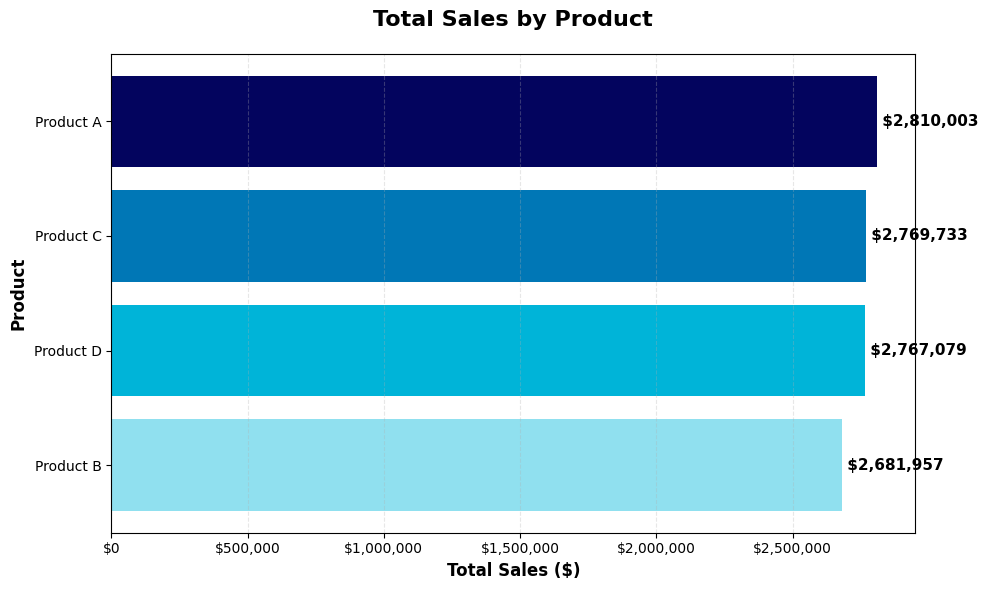

In [51]:
# VISUALIZATION 3: Sales by Product (Horizontal Bar Chart)
print("\n3. Sales Distribution by Product")
print("-" * 40)
# Aggregate data
sales_by_product = (df_clean.groupby('product')['sales']
.sum()
.sort_values())
# Create horizontal bar chart
plt.figure(figsize=(10, 6))
bars = plt.barh(sales_by_product.index,
sales_by_product.values,
color=['#90E0EF', '#00B4D8',
'#0077B6', '#03045E'])
# Add value labels at the end of bars
for i, (bar, value) in enumerate(zip(bars,sales_by_product.values)):
    plt.text(value, bar.get_y() + bar.get_height()/2,f' ${value:,.0f}',va='center', fontsize=11, fontweight='bold')
# Formatting
plt.title('Total Sales by Product',
fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Total Sales ($)', fontsize=12, fontweight='bold')
plt.ylabel('Product', fontsize=12, fontweight='bold')
plt.grid(axis='x', alpha=0.3, linestyle='--')
# Format x-axis
ax = plt.gca()
ax.xaxis.set_major_formatter(
plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

### Workshop Visualization 4: Profit vs Sales
[Code cell - from workshop]

use a sample of 10 percent to representate


4. Relationship: Profit vs Sales
----------------------------------------


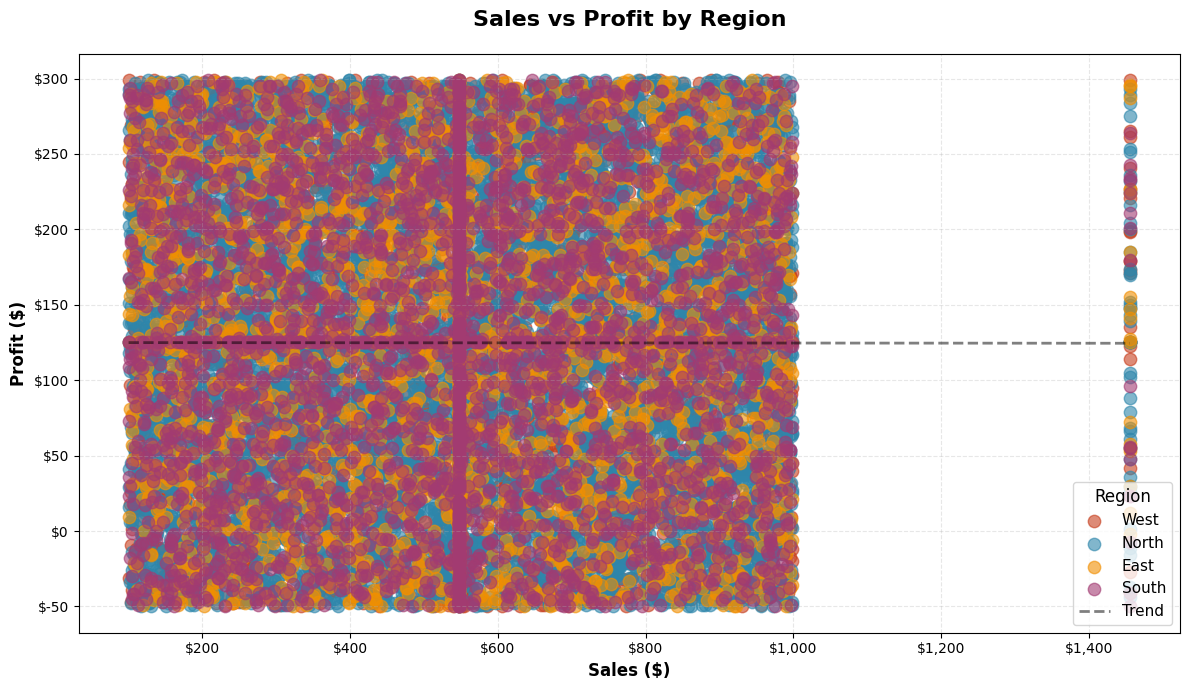

 Correlation between sales and profit: -0.001


In [ ]:
# VISUALIZATION 4: Profit vs Sales Scatter Plot
print("\n4. Relationship: Profit vs Sales")
print("-" * 40)
# Create scatter plot with color by region
plt.figure(figsize=(12, 7))
regions = df_clean['region'].unique()
colors = {'North': '#2E86AB', 'South': '#A23B72',
'East': '#F18F01', 'West': '#C73E1D'}
for region in regions:
    region_data = df_clean[df_clean['region'] == region]
    plt.scatter(region_data['sales'], region_data['profit'],
    label=region, alpha=0.6, s=80,
    color=colors.get(region, '#333333'))
# Add trend line
z = np.polyfit(df_clean['sales'], df_clean['profit'], 1)
p = np.poly1d(z)
x_trend = np.linspace(df_clean['sales'].min(),
df_clean['sales'].max(), 100)
plt.plot(x_trend, p(x_trend),
"--", color='black', linewidth=2,
alpha=0.5, label='Trend')
# Formatting
plt.title('Sales vs Profit by Region',
fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Sales ($)', fontsize=12, fontweight='bold')
plt.ylabel('Profit ($)', fontsize=12, fontweight='bold')
plt.legend(title='Region', fontsize=11, title_fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
# Format axes
ax = plt.gca()
ax.xaxis.set_major_formatter(
plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax.yaxis.set_major_formatter(
plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.tight_layout()
plt.show()
# Calculate correlation
correlation = df_clean['sales'].corr(df_clean['profit'])
print(f" Correlation between sales and profit: "
f"{correlation:.3f}")

### Workshop Visualization 5: Dashboard
[Code cell - from workshop]


5. Dashboard Overview
----------------------------------------


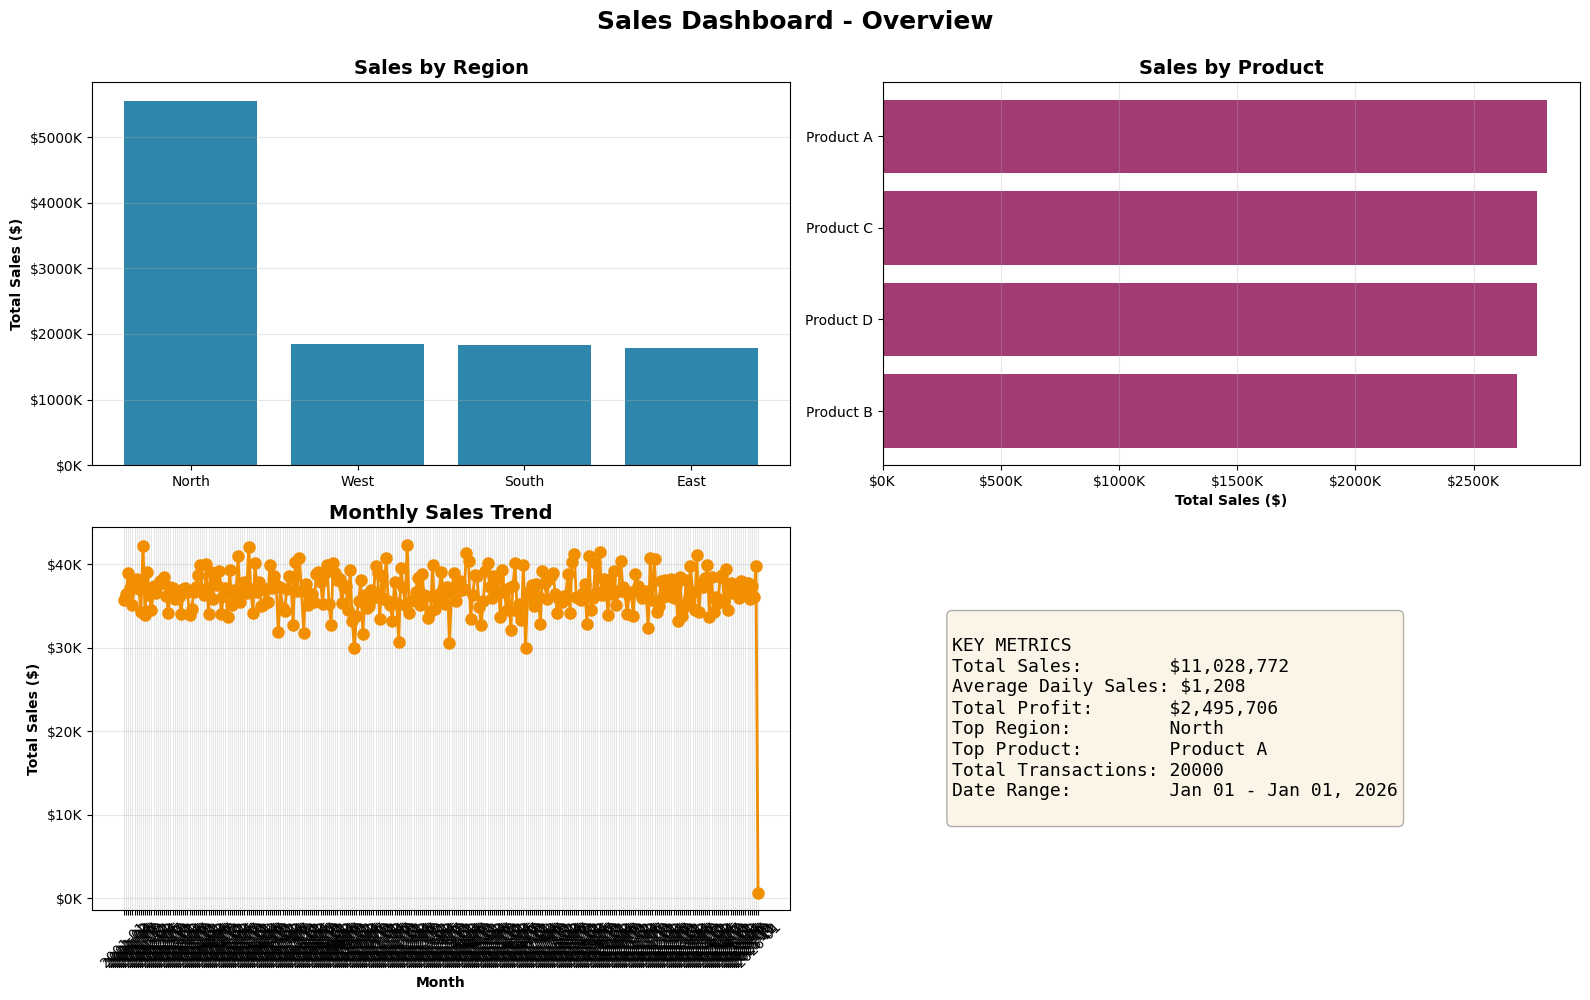

In [ ]:
# VISUALIZATION 5: Multi-panel Dashboard Style
print("\n5. Dashboard Overview")
print("-" * 40)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Sales Dashboard - Overview',
             fontsize=18, fontweight='bold', y=0.995)

# Panel 1: Sales by Region (Top Left)
sales_by_region = (df_clean.groupby('region')['sales']
                  .sum()
                  .sort_values(ascending=False))
axes[0, 0].bar(sales_by_region.index,
               sales_by_region.values, color='#2E86AB')
axes[0, 0].set_title('Sales by Region',
                     fontweight='bold', fontsize=14)
axes[0, 0].set_ylabel('Total Sales ($)', fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

# Panel 2: Sales by Product (Top Right)
sales_by_product = (df_clean.groupby('product')['sales']
                   .sum()
                   .sort_values())
axes[0, 1].barh(sales_by_product.index,
                sales_by_product.values, color='#A23B72')
axes[0, 1].set_title('Sales by Product',
                     fontweight='bold', fontsize=14)
axes[0, 1].set_xlabel('Total Sales ($)', fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)
axes[0, 1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

# Panel 3: Monthly Trend (Bottom Left)
df_clean['month'] = df_clean['date'].dt.to_period('M')
monthly_sales = df_clean.groupby('month')['sales'].sum()
axes[1, 0].plot(range(len(monthly_sales)),
                monthly_sales.values,
                marker='o', linewidth=2,
                markersize=8, color='#F18F01')
axes[1, 0].set_title('Monthly Sales Trend',
                     fontweight='bold', fontsize=14)
axes[1, 0].set_xlabel('Month', fontweight='bold')
axes[1, 0].set_ylabel('Total Sales ($)', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
axes[1, 0].set_xticks(range(len(monthly_sales)))
axes[1, 0].set_xticklabels([str(m) for m in monthly_sales.index],
                           rotation=45)

# Panel 4: Key Metrics (Bottom Right)
axes[1, 1].axis('off')
total_sales = df_clean['sales'].sum()
daily_sales = df_clean.groupby('date')['sales'].sum()
avg_daily = daily_sales.mean()
total_profit = df_clean['profit'].sum()
date_start = df_clean['date'].min().strftime('%b %d')
date_end = df_clean['date'].max().strftime('%b %d, %Y')

metrics_text = f"""
KEY METRICS
Total Sales:        ${total_sales:,.0f}
Average Daily Sales: ${avg_daily:,.0f}
Total Profit:       ${total_profit:,.0f}
Top Region:         {sales_by_region.index[0]}
Top Product:        {sales_by_product.index[-1]}
Total Transactions: {len(df_clean)}
Date Range:         {date_start} - {date_end}
"""
axes[1, 1].text(0.1, 0.5, metrics_text,
                fontsize=13, family='monospace',
                verticalalignment='center',
                bbox=dict(boxstyle='round',
                          facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

## PART 2: MY REDESIGNS
YOUR ORIGINAL WORK STARTS HERE!

### Redesign 1: [Improved Version of Visualization 2]
[Code cell - YOUR CODE]
[Output - YOUR VISUALIZATION]
In this redesing we are going to change the dates and use a Quarters frecuency instead for a better visualization and interpretation of the data,

Before any redesing wew should use IQR  method for outliers for the other categories/columns used at our visualizations

In [54]:
def iqr_method(series): #we define a function in order to clean our outliers if necesary
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return Q1, Q3, IQR, lower, upper

Q1_p, Q3_p, IQR_p, lower_p, upper_p = iqr_method(df_clean['profit'])
Q1_s, Q3_s, IQR_s, lower_s, upper_s = iqr_method(df_clean['sales'])

In [59]:
outliers_sales = (
    (df_clean['sales'] < lower_s) |
    (df_clean['sales'] > upper_s)
)

outliers_profit = (
    (df_clean['profit'] < lower_p) |
    (df_clean['profit'] > upper_p)
)


print(f"atipicos in sales -> {outliers_sales.sum()}")
print(f"atipicos in profit -> {outliers_profit.sum()}")

atipicos in sales -> 100
atipicos in profit -> 0


In [66]:
df_clean.loc[df_clean['sales'] > upper_s, 'sales'] = upper_s
df_clean.loc[df_clean['sales'] < lower_s, 'sales'] = lower_s
df_clean.loc[df_clean['profit'] > upper_p, 'profit'] = upper_p
df_clean.loc[df_clean['profit'] < lower_p, 'profit'] = lower_p


In [67]:
df_clean.info()
# ok we have a datatime so we can work with this type of Dtype to

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      20000 non-null  datetime64[ns]
 1   region    20000 non-null  object        
 2   product   20000 non-null  object        
 3   sales     20000 non-null  float64       
 4   profit    20000 non-null  float64       
 5   quantity  20000 non-null  int64         
 6   month     20000 non-null  period[M]     
dtypes: datetime64[ns](1), float64(2), int64(1), object(2), period[M](1)
memory usage: 1.1+ MB


ﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـ
Redesing 1 by cesar pinto
ﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ

/tmp/ipython-input-85610026.py:13: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  .resample('Q')['sales']


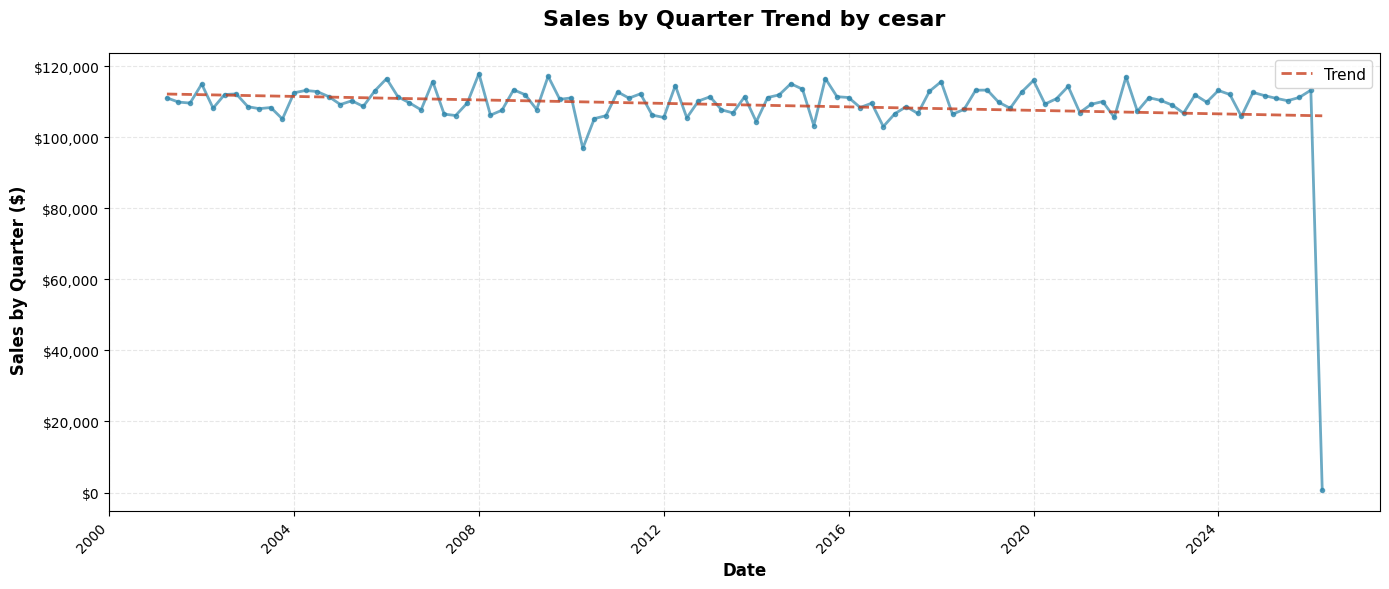

 Average  sales by quarter: $109,107.64
 Trend: Decreasing


In [68]:
print("ﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـ"*60)
print("Redesing 1 by cesar pinto")
print("ﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـ"*60)
# VISUALIZATION 2: Sales Trend Over Time (Line Chart) #


# Set the 'date' column as the DataFrame index for resampling gemini asisted with index
df_indexed_by_date = df_clean.set_index('date')

# So a benefit of datetime index is that we can use Quarters
sales_per_quarter = (
    df_indexed_by_date #"gemini asisted"
    .resample('Q')['sales']
    .sum()
    .reset_index()
)

#Create line chart
plt.figure(figsize=(14, 6))
plt.plot(sales_per_quarter['date'], sales_per_quarter['sales'],
        linewidth=2, color='#2E86AB',
        marker='o', markersize=3, alpha=0.7)

z = np.polyfit(range(len(sales_per_quarter)),
              sales_per_quarter['sales'], 1)

p = np.poly1d(z)
plt.plot(sales_per_quarter['date'],
        p(range(len(sales_per_quarter))),
        "--", color='#C73E1D',
        linewidth=2, alpha=0.8, label='Trend')



# Formatting
plt.title('Sales by Quarter Trend by cesar',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel(' Sales by Quarter ($)', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=11)
# Format y-axis
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(f" Average  sales by quarter: "f"${sales_per_quarter['sales'].mean():,.2f}")
print(f" Trend: {'Increasing' if z[0] > 0 else 'Decreasing'}")

Redesign 2: [Improved Version of Visualization 4]
The problem with this 4th visualization is that we have too much data( OVERPLOTTING PROBLEM) in the relationship between profits and sales by region  and it is confusing and hard to understand what it is telling us to visualizate so we are going to sample data and divide it in to a plot by region for a better interpretation. one

ﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـ

4. Relationship: Profit vs Sales sample
ﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ

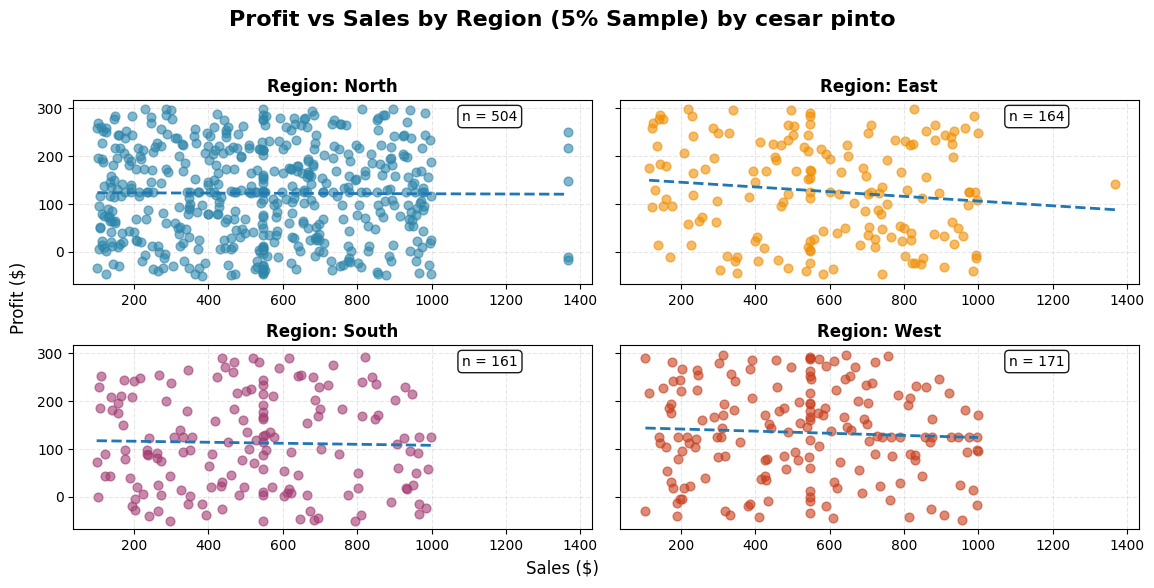

In [69]:
print("ﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـ"*60)
print("\n4. Relationship: Profit vs Sales sample")
print("ﮩ٨ـﮩﮩ٨ـ♡ﮩ٨ـﮩﮩ٨ـ" * 40)

#we should create a sample of our data
df_muestreo = df_clean.sample(frac=0.05, random_state=42)
regions = df_muestreo['region'].unique()
#then we create the plotis
fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True, sharey=True)
axes = axes.flatten() #from data technique called small multiples and flatten() means  turn into a multidimentional array

colores_jorge = {
    'North': '#2E86AB',
    'South': '#A23B72',
    'East':  '#F18F01',
    'West':  '#C73E1D'
}

count_per_Zone = (
    df_muestreo
    .groupby('region')
    .size()
    .to_dict()
)

#gemini asisted code;
for ax, region in zip(axes, regions):
    region_data = df_muestreo[df_muestreo['region'] == region]

    ax.scatter(
        region_data['sales'],
        region_data['profit'],
        color=colors.get(region, '#333333'), #defined at colores jorge
        alpha=0.6,
        label=region,
        s=40
    )


    z = np.polyfit(region_data['sales'], region_data['profit'], 1)
    p = np.poly1d(z)
    n = count_per_Zone.get(region, 0)

    ax.text(
    0.75, 0.95,
    f'n = {n}',
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        alpha=0.9
    )
)
    x_vals = np.linspace(
        region_data['sales'].min(),
        region_data['sales'].max(),
        100
    )

    ax.plot(x_vals, p(x_vals), "--", linewidth=2)
    ax.tick_params(labelbottom=True)

    ax.set_title(f"Region: {region}", fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    fig.suptitle(
    'Profit vs Sales by Region (5% Sample) by cesar pinto',
    fontsize=16,
    fontweight='bold'
)

fig.text(0.5, 0.04, 'Sales ($)', ha='center', fontsize=12)
fig.text(0.04, 0.5, 'Profit ($)', va='center',
         rotation='vertical', fontsize=12)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
plt.show()





Redesign 3: [Improved Version of Visualization 3]
i just fixed the size of the plot


3. Sales Distribution by Product
----------------------------------------


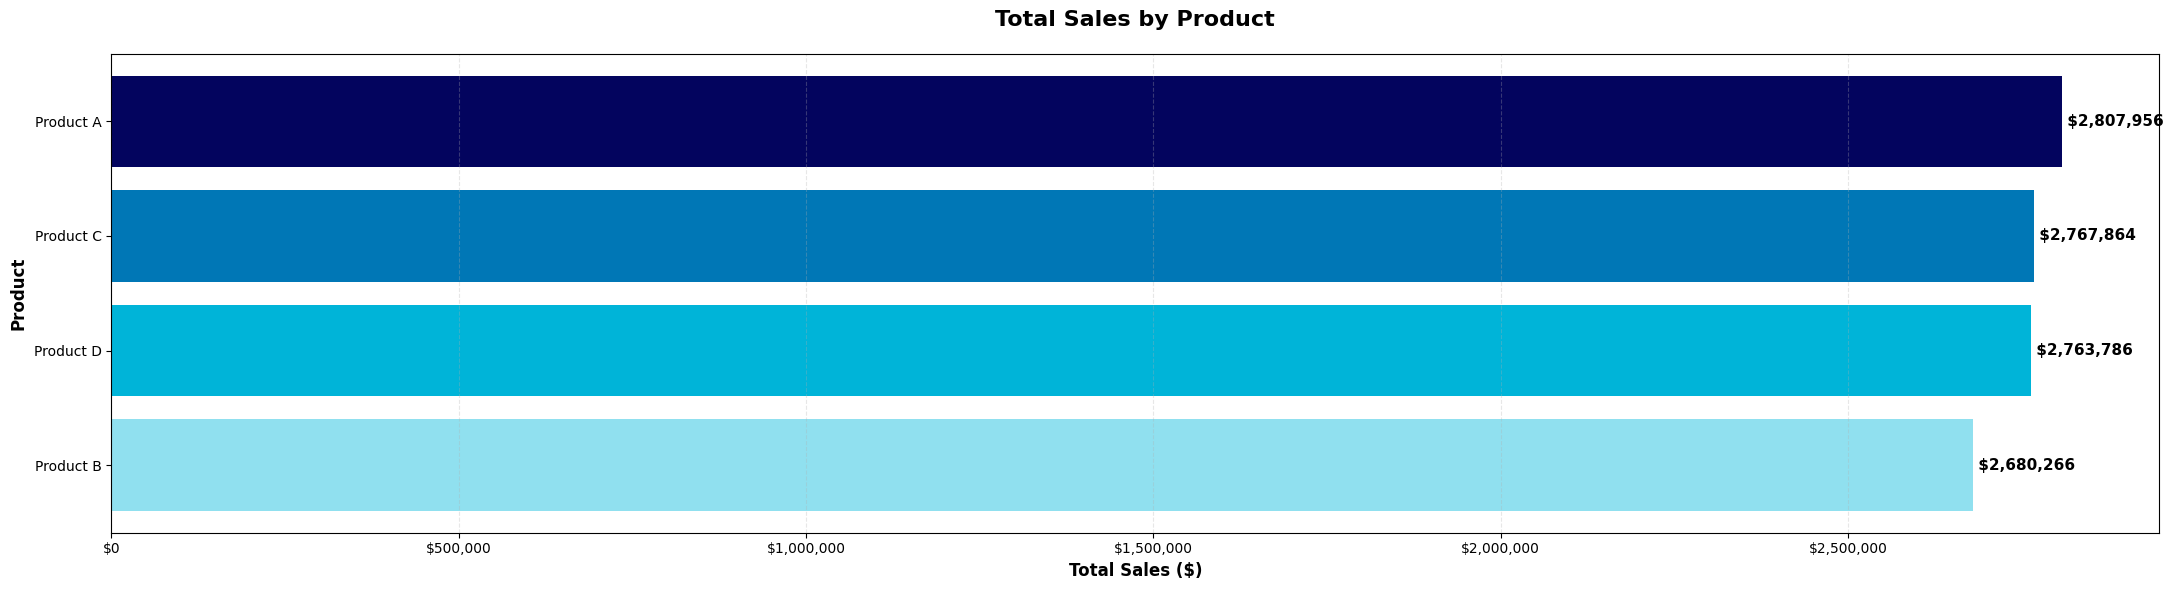

In [65]:
# VISUALIZATION 3: Sales by Product (Horizontal Bar Chart)
print("\n3. Sales Distribution by Product")
print("-" * 40)
# Aggregate data
sales_by_product = (df_clean.groupby('product')['sales']
.sum()
.sort_values())
# Create horizontal bar chart
plt.figure(figsize=(22, 6))
bars = plt.barh(sales_by_product.index,
sales_by_product.values,
color=['#90E0EF', '#00B4D8',
'#0077B6', '#03045E'])
# Add value labels at the end of bars
for i, (bar, value) in enumerate(zip(bars,sales_by_product.values)):
    plt.text(value, bar.get_y() + bar.get_height()/2,f' ${value:,.0f}',va='center', fontsize=11, fontweight='bold')
# Formatting
plt.title('Total Sales by Product',
fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Total Sales ($)', fontsize=12, fontweight='bold')
plt.ylabel('Product', fontsize=12, fontweight='bold')
plt.grid(axis='x', alpha=0.3, linestyle='--')
# Format x-axis
ax = plt.gca()
ax.xaxis.set_major_formatter(
plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

Redesign 4: [Improved Version of Visualization 5]
monthly sales trend; this plot is dirty and oversaturated
we fixed by using yearly using date time


/tmp/ipython-input-3394905383.py:5: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  .resample('Y')['sales']


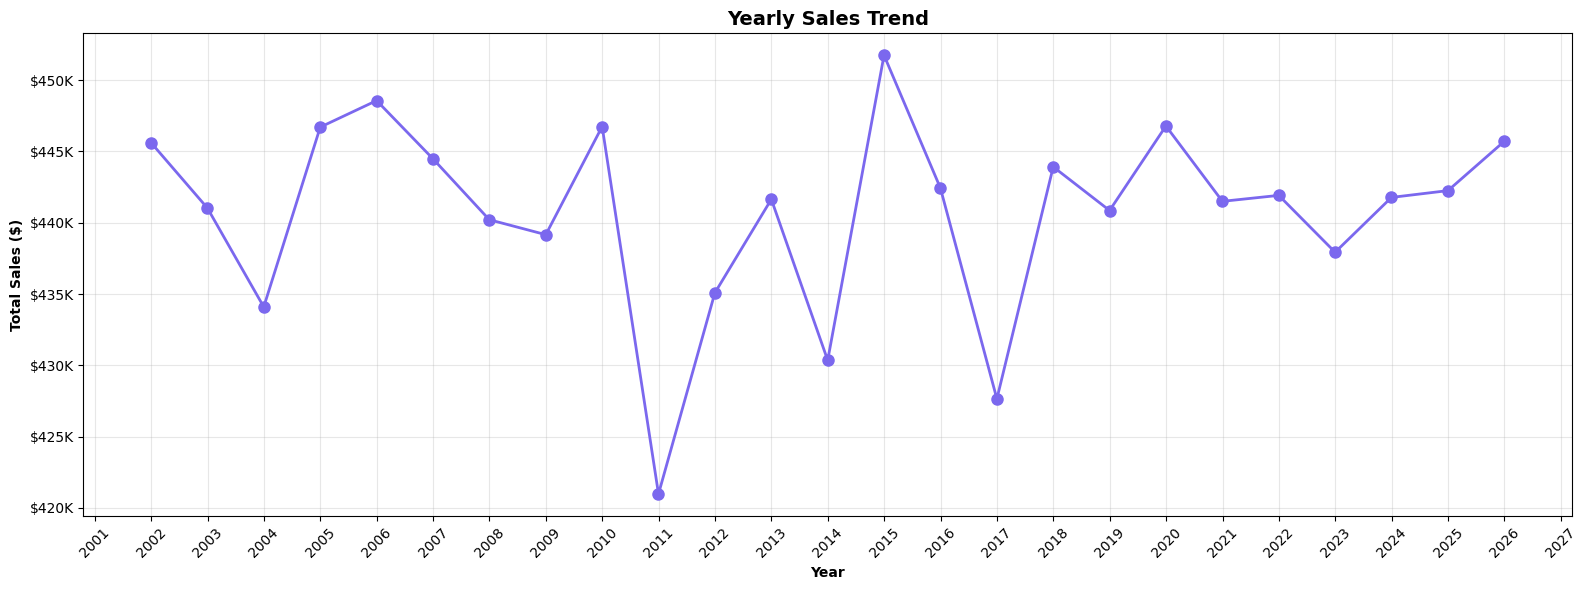

In [84]:

#by using a time series
monthly_sales = (
    df_clean
    .set_index('date')
    .resample('Y')['sales']
    .sum()
)
#we remove the last year
monthly_sales = monthly_sales.iloc[:-1]

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o',
    linewidth=2,
    markersize=8,
    color='#7B68EE'
)

ax.set_title('Yearly Sales Trend', fontweight='bold', fontsize=14)
ax.set_xlabel('Year', fontweight='bold')
ax.set_ylabel('Total Sales ($)', fontweight='bold')
ax.grid(True, alpha=0.3)


ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K')
)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Redesign 4: [Improved Version of Visualization 5]
both ploti of the dashbourt were out of rangue we just change it and extend the y axe for a better visualizaition, i changue the second one into a vertical one just in order to not distract wtih diferent visual elements.


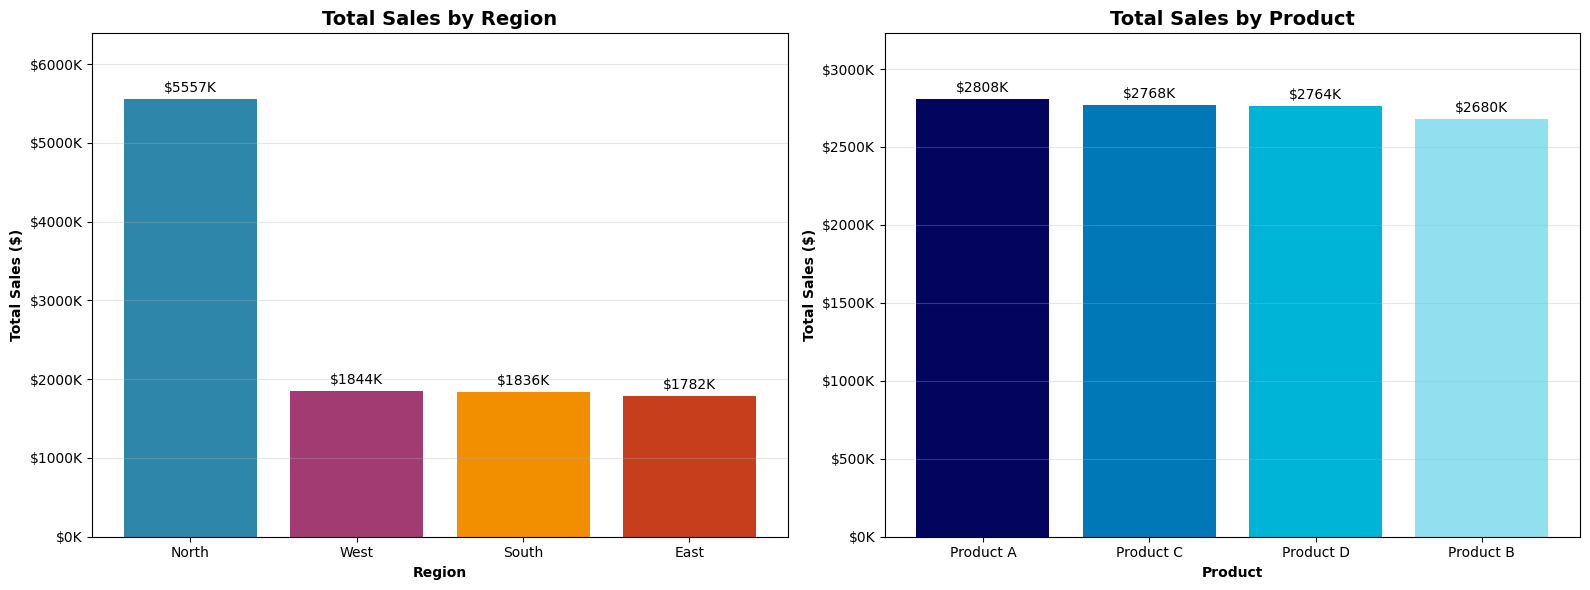

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sales_by_region = (
    df_clean.groupby('region')['sales']
    .sum()
    .sort_values(ascending=False)
)

bars_region = axes[0].bar(
    sales_by_region.index,
    sales_by_region.values,
    color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
)

y_max_region = sales_by_region.values.max()
axes[0].set_ylim(0, y_max_region * 1.15)

axes[0].set_title('Total Sales by Region', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Total Sales ($)', fontweight='bold')
axes[0].set_xlabel('Region', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K')
)


axes[0].bar_label(
    bars_region,
    labels=[f'${v/1000:.0f}K' for v in sales_by_region.values],
    padding=3,
    fontsize=10
)


sales_by_product = (
    df_clean.groupby('product')['sales']
    .sum()
    .sort_values(ascending=False)
)

bars_product = axes[1].bar(
    sales_by_product.index,
    sales_by_product.values,
    color=['#03045E', '#0077B6', '#00B4D8', '#90E0EF']
)

y_max_product = sales_by_product.values.max()
axes[1].set_ylim(0, y_max_product * 1.15)

axes[1].set_title('Total Sales by Product', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Total Sales ($)', fontweight='bold')
axes[1].set_xlabel('Product', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K')
)


axes[1].bar_label(
    bars_product,
    labels=[f'${v/1000:.0f}K' for v in sales_by_product.values],
    padding=3,
    fontsize=10
)

plt.tight_layout()
plt.show()
